# Shared latent rollout across mechanical datasets

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists(): PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path: sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.latent.experiment import evaluate_rollout_horizons, run_latent_experiment, seed_everything
from lss.latent.simulation import r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
PAPER_DPI = 180
PAPER_FIGSIZE = (5.4, 4.2)
plt.rcParams.update({'figure.dpi': PAPER_DPI, 'savefig.dpi': 400})
DEVICE = resolve_device('auto')
DEVICE

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Configuration

In [2]:
SEED = 3456456


FORCE_TRAIN = False
TRAIN_PER_SOURCE = 40
VAL_PER_SOURCE = 15
TRAIN_STEPS_PER_SIM = 150
PROPAGATOR_STRIDE = 1
MAX_EPOCHS = 30
PATIENCE = 3
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
LATENT_DIM = 32

ROLLOUT_STEPS = [5, 10, 25, 50, 75, 100]
DATASETS = {
    'reid': {'label': 'Reid', 'path': PROJECT_ROOT/'data'/'reid_200_frames.pt'},
    'depablo_low_temp': {'label': 'de Pablo low-T', 'path': PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'},
    'depablo_mixed_temp': {'label': 'de Pablo mixed-T', 'path': PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt'},
}
for spec in DATASETS.values(): assert spec['path'].exists(), spec['path']
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'06b_mixed_dataset_shared_latent_rollout_boxnorm'
OUTPUT.mkdir(parents=True, exist_ok=True)
MODEL_CONFIG = {
    'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 256,
    'batch_graphs': 32,
    'coordinate_normalization': 'position_normalization',
    'edge_mode': 'compact_stored',
}
PROPAGATOR_SOURCES = tuple(DATASETS)
AE_CACHE = None
MODEL_CACHE = OUTPUT/'model_common_three_sources_physical_context_no_history.pt'
print({'device': str(DEVICE), 'pretrained_ae_cache': AE_CACHE, 'propagator_sources': PROPAGATOR_SOURCES, 'training_steps_per_trajectory': TRAIN_STEPS_PER_SIM, 'propagator_cache': str(MODEL_CACHE)})

{'device': 'cuda', 'pretrained_ae_cache': None, 'propagator_sources': ('reid', 'depablo_low_temp', 'depablo_mixed_temp'), 'training_steps_per_trajectory': 150, 'propagator_cache': '/home/alexz/Documents/course_project/notebooks/results/06b_mixed_dataset_shared_latent_rollout_boxnorm/model_common_three_sources_physical_context_no_history.pt'}


## Shared autoencoder and propagator

In [3]:
ae_config = {
    'latent_dim': LATENT_DIM, 'latent_tokens': MODEL_CONFIG['latent_tokens'],
    'hidden_size': MODEL_CONFIG['hidden_size'], 'model': 'attention',
    'edge_feature_dim': 8, 'target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
    'max_train_frames_per_sim': TRAIN_STEPS_PER_SIM + 1,
    'val_frame_skip': 1, 'max_val_frames_per_sim': TRAIN_STEPS_PER_SIM + 1,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    'balance_sources': False, 'mix_sources': True,
    'pratio_eval_every': 1, 'pratio_eval_step': 100,
}
propagator_config = {
    'max_train_transitions_per_sim': TRAIN_STEPS_PER_SIM,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    'hidden_size': 64, 'objective': 'one_step',
    'model': 'delta_mlp', 'loss': 'delta', 'step_stride': PROPAGATOR_STRIDE,
    'multistep_horizons': [1],
    'mix_sources': True, 'balance_sources': False, 'source_loss_reduction': 'equal',
    'train_trajectories_per_source': {key: TRAIN_PER_SOURCE for key in PROPAGATOR_SOURCES},
    'val_trajectories_per_source': {key: VAL_PER_SOURCE for key in PROPAGATOR_SOURCES},
    'use_static_context': True, 'context_dim': 16,
    'context_pool': 'mean', 'rollout_eval_every_epoch': True, 'rollout_eval_interval': 1,
    'rollout_eval_horizons': [100],
    'rollout_eval_sims_per_source': VAL_PER_SOURCE, 'rollout_eval_sources': PROPAGATOR_SOURCES,
}
experiment_config = {
    'ae_config': ae_config, 'propagator_config': propagator_config,
    'dataset_name': 'mixed_sources_shared', 'split_seed': SEED, 'split_stratify_temperature': False,
    'min_train_p_ratio': None, 'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': MODEL_CONFIG['batch_graphs'],
    'frame_skip': 1, 'train_frame_start_order': 0,
    'edge_mode': MODEL_CONFIG['edge_mode'], 'static_context_use_physical_reference': True,
    'coordinate_normalization': MODEL_CONFIG['coordinate_normalization'],
    'rollout_steps_grid': ROLLOUT_STEPS,
    'rollout_final_eval_sims_per_source': 30,
    'early_stop_min_delta': 1e-5, 'should_rollout': True, 'should_train_propagator': True,
    'pretrained_ae_cache_path': AE_CACHE,
    'pretrained_ae_config_keys': ['split_seed', 'coordinate_normalization', 'edge_mode', 'pos_dim', 'latent_dim', 'latent_tokens', 'hidden_size', 'autoencoder_model', 'edge_feature_dim', 'node_feature_mode', 'ae_target_mode', 'ae_max_train_frames_per_sim', 'ae_max_val_frames_per_sim'],
    'pretrained_ae_require_matching_normalizers': True,
    'force_train': FORCE_TRAIN, 'force_train_autoencoder': False, 'cache_path': str(MODEL_CACHE),
    'cache_require_matching_config': True, 'model_seed': SEED, 'repeat_idx': 1,
}
mixture = [{'name': key, 'label': spec['label'], 'path': str(spec['path']), 'train_count': TRAIN_PER_SOURCE, 'val_count': VAL_PER_SOURCE} for key,spec in DATASETS.items()]
source = {
    'dataset_name': 'mixed_sources_shared', 'source_name': 'three-source AE / three-source one-step physical-context propagator mixture', 'label': 'shared AE three sources, one-step physical-context propagator',
    'path': str(next(iter(DATASETS.values()))['path']), 'dataset_mixture': mixture,
}
seed_everything(SEED)
result = run_latent_experiment(source, experiment_config, device=DEVICE)
display(result['split_info'])
propagator_history_columns = ['epoch', *[f'{split}_source_{source_key}_loss_norm' for split in ('train', 'val') for source_key in PROPAGATOR_SOURCES], *[f'val_rollout_source_{source_key}_p_ratio_r2' for source_key in PROPAGATOR_SOURCES]]
display(result['dyn_history'].reindex(columns=propagator_history_columns).tail().round(3))

loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/06b_mixed_dataset_shared_latent_rollout_boxnorm/model_common_three_sources_physical_context_no_history.pt


,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,40,40,15,47
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,40,40,15,145
2,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,40,40,15,245


,epoch,train_source_reid_loss_norm,train_source_depablo_low_temp_loss_norm,train_source_depablo_mixed_temp_loss_norm,val_source_reid_loss_norm,val_source_depablo_low_temp_loss_norm,val_source_depablo_mixed_temp_loss_norm,val_rollout_source_reid_p_ratio_r2,val_rollout_source_depablo_low_temp_p_ratio_r2,val_rollout_source_depablo_mixed_temp_p_ratio_r2
5,6,0.001,0.026,2.842,0.002,0.032,1.615,0.433,0.966,0.928
6,7,0.001,0.026,2.838,0.002,0.025,1.623,0.506,0.970,0.909
7,8,0.001,0.025,2.834,0.001,0.027,1.609,0.487,0.974,0.916
8,9,0.001,0.026,2.822,0.002,0.023,1.614,0.466,0.973,0.907
9,10,0.000,0.023,2.830,0.002,0.025,1.611,0.402,0.973,0.891


p_ratio_r2                     \
method        AE reconstruction ceiling propagator rollout   
rollout_steps                                                
5                                 0.387              0.483   
10                                0.317              0.393   
25                                0.763              0.674   
50                                0.853              0.847   
75                                0.905              0.887   
100                               0.939              0.925   

                           position_mse                     
method        AE reconstruction ceiling propagator rollout  
rollout_steps                                               
5                                   0.0                0.0  
10                                  0.0                0.0  
25                                  0.0                0.0  
50                                  0.0                0.0  
75                                  0.0                0.0  
100                                 0.0                0.0

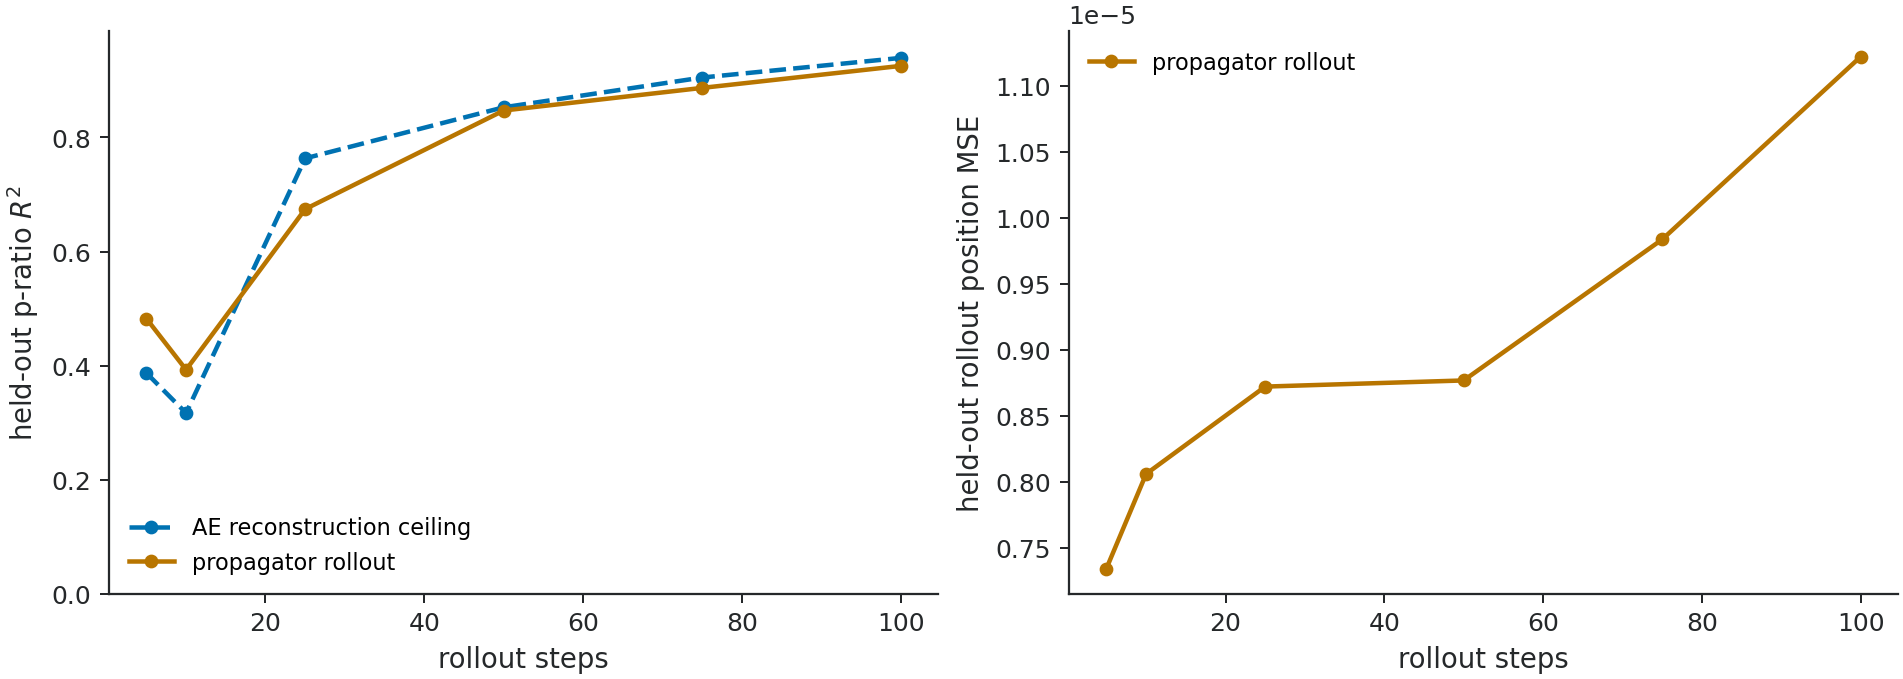

In [4]:
def pooled_horizon_metrics(rows, method):
    records = []
    for steps, group in rows.query("split == 'test'").groupby('rollout_steps', sort=True):
        valid = group.dropna(subset=['true_p_ratio', 'pred_p_ratio'])
        records.append({
            'method': method, 'rollout_steps': int(steps),
            'p_ratio_r2': r2_score(valid.true_p_ratio, valid.pred_p_ratio) if len(valid) > 1 else np.nan,
            'position_mse': group.final_pos_mse.mean(),
        })
    return records

horizon_metrics = pd.DataFrame([
    *pooled_horizon_metrics(result['ae_reconstruction_rows'], 'AE reconstruction ceiling'),
    *pooled_horizon_metrics(result['rollout_rows'], 'propagator rollout'),
])
display(horizon_metrics.pivot(index='rollout_steps', columns='method', values=['p_ratio_r2', 'position_mse']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.8), constrained_layout=True)
for method, linestyle in [('AE reconstruction ceiling', '--'), ('propagator rollout', '-')]:
    curve = horizon_metrics.query('method == @method').sort_values('rollout_steps')
    axes[0].plot(curve.rollout_steps, curve.p_ratio_r2, marker='o', markersize=4.5, lw=1.8,
                 ls=linestyle, color=PAPER_COLORS['blue'] if method.startswith('AE') else PAPER_COLORS['orange'], label=method)
rollout_curve = horizon_metrics.query("method == 'propagator rollout'").sort_values('rollout_steps')
axes[1].plot(rollout_curve.rollout_steps, rollout_curve.position_mse, marker='o', markersize=4.5, lw=1.8, color=PAPER_COLORS['orange'], label='propagator rollout')
axes[0].axhline(0, color=PAPER_COLORS['slate'], lw=.8)
axes[0].set_ylim(bottom=0)
style_axes(axes[0], xlabel='rollout steps', ylabel='held-out p-ratio $R^2$', legend=True)
style_axes(axes[1], xlabel='rollout steps', ylabel='held-out rollout position MSE', legend=True)
plt.show()

,source,mean_delta_loss,std_delta_loss
0,Reid,0.00050,0.00010
1,de Pablo low-T,0.02753,0.00866
2,de Pablo mixed-T,2.72715,0.97032


,pair,mean,median,std,negative_fraction,n
0,Reid ↔ de Pablo low-T,-0.007,-0.006,0.024,0.594,32
1,Reid ↔ de Pablo mixed-T,-0.011,-0.005,0.033,0.531,32
2,de Pablo low-T ↔ de Pablo mixed-T,0.086,0.189,0.531,0.469,32


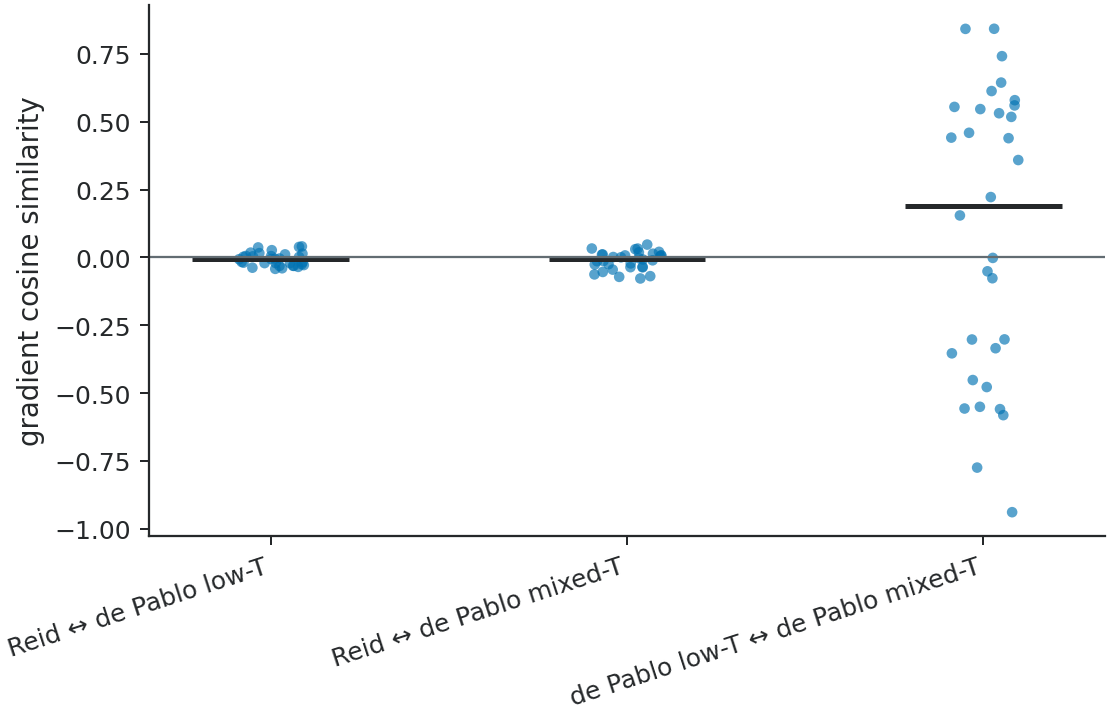

,split,source,n,rollout_p_ratio_r2
0,held-out,Reid,30,0.849
1,held-out,de Pablo low-T,30,0.965
2,held-out,de Pablo mixed-T,30,0.918


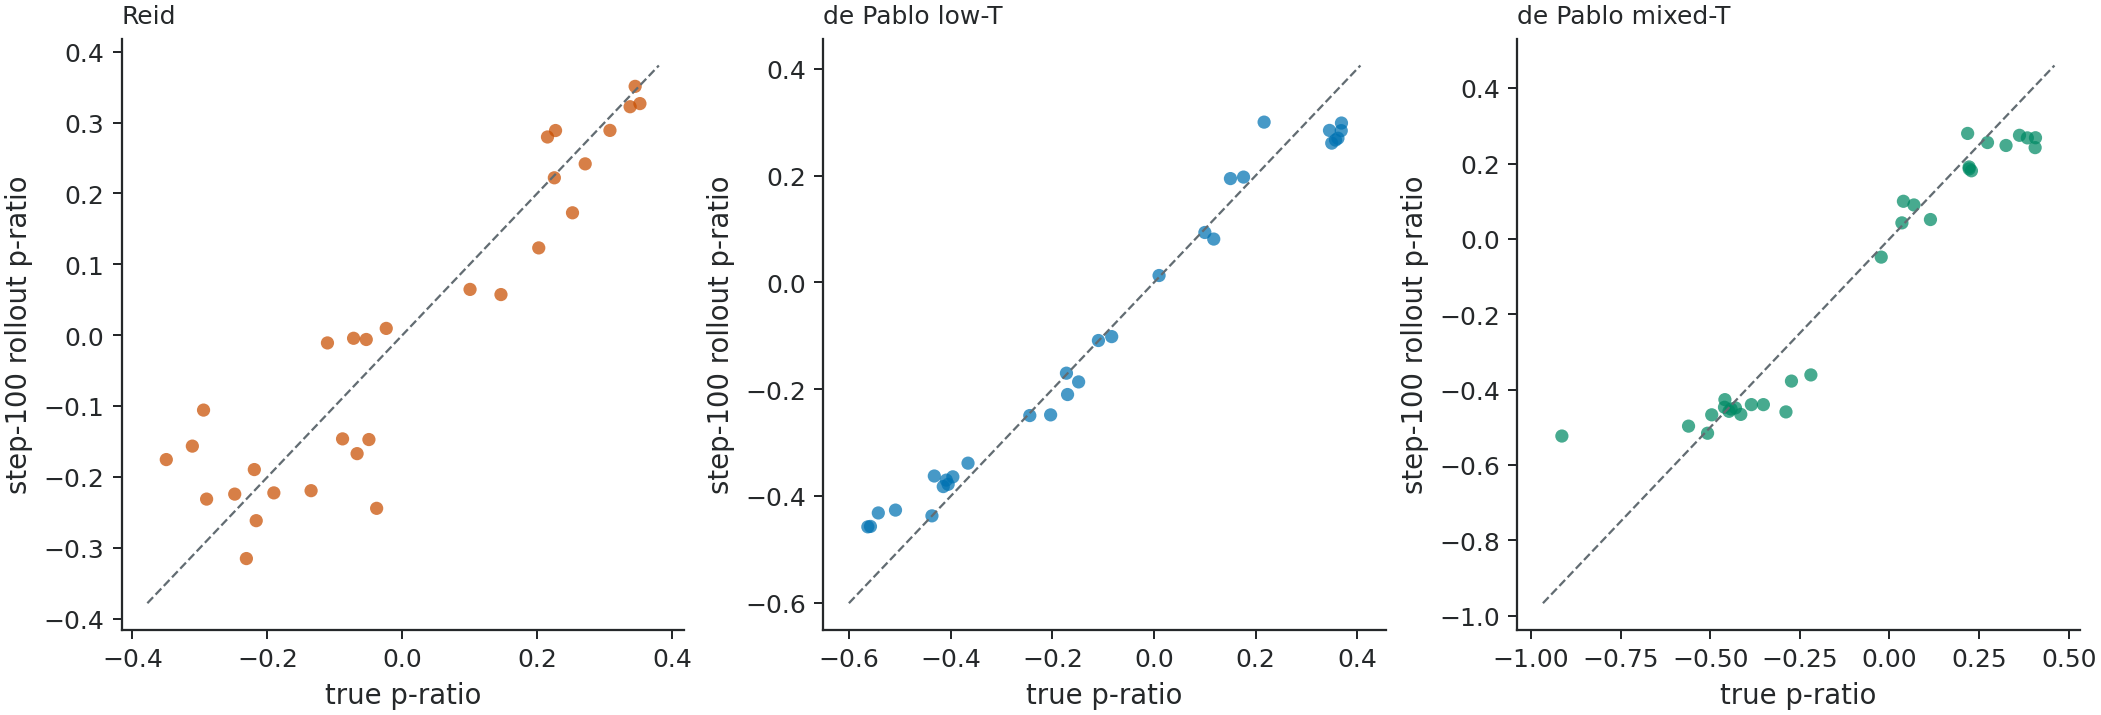

In [5]:
GRADIENT_BATCH_SIZE = 32
GRADIENT_PROBES = 32

def gradient_batch_rows(source_key, probe_index):
    candidates = [(sim_idx, step, step + PROPAGATOR_STRIDE) for sim_idx, simulation in enumerate(result['train_data']) if getattr(simulation[0], 'source_name', None) == source_key for step in range(TRAIN_STEPS_PER_SIM - PROPAGATOR_STRIDE + 1)]
    generator = torch.Generator().manual_seed(SEED + sum(map(ord, source_key)) + 1009 * probe_index)
    chosen = torch.randperm(len(candidates), generator=generator)[:GRADIENT_BATCH_SIZE].tolist()
    return [candidates[index] for index in chosen]

def source_gradient(source_key, probe_index):
    from lss.latent.training import encode_reference_context, encode_transition_batch
    dyn, ae = result['dyn'], result['ae']
    stats, normalizers = result['latent_stats'], result['normalizers']
    sims, rows = result['train_data'], gradient_batch_rows(source_key, probe_index)
    was_training = dyn.training
    dyn.eval()
    z0, z1 = encode_transition_batch(ae, sims, rows, pos_dim=2, node_feature_mode='normalized_delta', normalizers=normalizers, device=DEVICE)
    contexts = torch.stack([encode_reference_context(ae, sims[int(row[0])], pos_dim=2, normalizers=normalizers, device=DEVICE, pool_mode='mean') for row in rows])
    prediction = dyn(stats.normalize_z(z0), stats.normalize_context(contexts))
    loss = (prediction - stats.normalize_dz(z1 - z0)).square().mean()
    parameters = [parameter for parameter in dyn.parameters() if parameter.requires_grad]
    gradients = torch.autograd.grad(loss, parameters, allow_unused=True)
    vector = torch.cat([gradient.reshape(-1) for gradient in gradients if gradient is not None]).detach()
    dyn.train(was_training)
    return float(loss.detach()), vector

gradient_losses, gradient_vectors = {source_key: [] for source_key in PROPAGATOR_SOURCES}, {source_key: [] for source_key in PROPAGATOR_SOURCES}
for probe_index in range(GRADIENT_PROBES):
    for source_key in PROPAGATOR_SOURCES:
        loss, vector = source_gradient(source_key, probe_index)
        gradient_losses[source_key].append(loss)
        gradient_vectors[source_key].append(vector)
loss_summary = pd.DataFrame([{'source': DATASETS[source_key]['label'], 'mean_delta_loss': np.mean(values), 'std_delta_loss': np.std(values, ddof=1)} for source_key, values in gradient_losses.items()])
cosine_rows = []
for left_index, left in enumerate(PROPAGATOR_SOURCES):
    for right in PROPAGATOR_SOURCES[left_index + 1:]:
        for probe_index, (left_gradient, right_gradient) in enumerate(zip(gradient_vectors[left], gradient_vectors[right])):
            cosine = (torch.dot(left_gradient, right_gradient) / (left_gradient.norm() * right_gradient.norm()).clamp_min(1e-12)).item()
            cosine_rows.append({'pair': f'{DATASETS[left]["label"]} ↔ {DATASETS[right]["label"]}', 'probe': probe_index, 'cosine': cosine})
gradient_cosines = pd.DataFrame(cosine_rows)
cosine_summary = gradient_cosines.groupby('pair', sort=False).cosine.agg(mean='mean', median='median', std='std', negative_fraction=lambda values: (values < 0).mean(), n='size').reset_index()
display(loss_summary.round(5))
display(cosine_summary.round(3))
fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
pair_order = cosine_summary.pair.tolist()
for pair_index, pair in enumerate(pair_order):
    values = gradient_cosines.loc[gradient_cosines.pair == pair, 'cosine'].to_numpy(float)
    jitter = np.random.default_rng(SEED + pair_index).uniform(-.10, .10, size=len(values))
    ax.scatter(np.full(len(values), pair_index) + jitter, values, s=18, alpha=.65, color=PAPER_COLORS['blue'], edgecolor='none')
    ax.hlines(np.median(values), pair_index - .22, pair_index + .22, color=PAPER_COLORS['ink'], linewidth=2)
ax.axhline(0, color=PAPER_COLORS['slate'], linewidth=.9)
ax.set_xticks(range(len(pair_order)), pair_order, rotation=18, ha='right')
style_axes(ax, xlabel='', ylabel='gradient cosine similarity', legend=False)
plt.show()

heldout_rows = result['rollout_rows'].query("split == 'test' and rollout_steps == 100").copy()
heldout_summary = []
for source_key in PROPAGATOR_SOURCES:
    source_rows = heldout_rows.loc[heldout_rows.source == source_key]
    heldout_summary.append({'split': 'held-out', 'source': DATASETS[source_key]['label'], 'n': len(source_rows), 'rollout_p_ratio_r2': r2_score(source_rows.true_p_ratio, source_rows.pred_p_ratio) if len(source_rows) > 1 else np.nan})
display(pd.DataFrame(heldout_summary).round(3))

scatter_rows = {source_key: heldout_rows.loc[heldout_rows.source == source_key].copy() for source_key in PROPAGATOR_SOURCES}
scatter_sources = PROPAGATOR_SOURCES
fig, axes = plt.subplots(1, len(scatter_sources), figsize=(3.9 * len(scatter_sources), 4.0), constrained_layout=True)
for ax, source_key in zip(np.atleast_1d(axes), scatter_sources):
    rows = scatter_rows[source_key].dropna(subset=['true_p_ratio', 'pred_p_ratio'])
    if rows.empty:
        ax.text(.5, .5, 'no finite rollout pairs', transform=ax.transAxes, ha='center', va='center', color=PAPER_COLORS['slate'])
    else:
        ax.scatter(rows.true_p_ratio, rows.pred_p_ratio, s=28, alpha=.72, color=dataset_color(source_key), edgecolor='none')
        limits = np.r_[rows.true_p_ratio, rows.pred_p_ratio]
        lo, hi = np.nanmin(limits), np.nanmax(limits)
        pad = .04 * max(hi - lo, 1e-6)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', color=PAPER_COLORS['slate'], lw=.9)
    style_axes(ax, xlabel='true p-ratio', ylabel='step-100 rollout p-ratio', legend=False)
    ax.set_title(DATASETS[source_key]['label'], loc='left', fontsize=10)
plt.show()

## Held-out rollout curves and AE ceiling


In [6]:
# The pooled held-out horizon plot is shown above.
